# BCDU-Net Segmentation
This notebook implements and trains the BCDU-Net (Bi-directional ConvLSTM U-Net with Densely connected convolutions) for skin lesion segmentation. We use the preprocessed image-mask pairs from Notebook 12.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-03-04 17:24:13.050143: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 17:24:13.623953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 17:24:25.396697: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_SEG_DIR = DATA_DIR / "processed" / "segmentation"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models" / "segmentation"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 8

## 1. Dataset Loader
We load image-mask pairs directly from disk. Images are normalized to [0, 1] and masks are binary (0 or 1).

In [3]:
def load_image_mask(img_path, mask_path):
    img  = tf.io.read_file(img_path)
    img  = tf.image.decode_jpeg(img, channels=3)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method='nearest')
    mask = tf.cast(mask > 127, tf.float32)

    return img, mask

In [4]:
def augment_pair(img, mask):
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    # Random brightness
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask

In [5]:
def make_dataset(split, batch_size=BATCH_SIZE, augment=False):
    img_dir  = PROCESSED_SEG_DIR / split / "images"
    mask_dir = PROCESSED_SEG_DIR / split / "masks"

    img_paths  = sorted([str(p) for p in img_dir.glob("*.jpg")])
    mask_paths = [
        str(mask_dir / (Path(p).stem + ".png")) for p in img_paths
    ]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, len(img_paths)

In [6]:
train_ds, n_train = make_dataset("train", augment=True)
val_ds,   n_val   = make_dataset("val")
test_ds,  n_test  = make_dataset("test")

print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

Train: 1815, Val: 389, Test: 390


I0000 00:00:1772645072.978926  149312 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


## 2. BCDU-Net Architecture

In [7]:
def dense_conv_block(x, filters, n_dense=3):
    """Densely connected convolutional block."""
    dense_outputs = [x]
    for _ in range(n_dense):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        dense_outputs.append(x)
        x = layers.Concatenate()(dense_outputs)
    return x

In [8]:
def encoder_block(x, filters):
    skip = dense_conv_block(x, filters)
    pool = layers.MaxPooling2D(2)(skip)
    return skip, pool

In [9]:
def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = dense_conv_block(x, filters)
    return x

In [10]:
def bottleneck_bilstm(x, filters):
    """Bi-directional ConvLSTM bottleneck — processes spatial sequence in both directions."""
    # Add time dimension: (B, H, W, C) -> (B, 1, H, W, C) processed as sequences along height
    # Reshape to (B, H, W, C) -> treat rows as time steps -> (B, H, W, C)
    h = x.shape[1] or IMG_SIZE
    w = x.shape[2] or IMG_SIZE
    c = x.shape[3]

    # (B, H, W, C) -> (B, H, W, C) via ConvLSTM2D with sequence along batch
    x = layers.Reshape((1, h, w, c))(x)
    x = layers.Bidirectional(
        layers.ConvLSTM2D(filters, 3, padding='same', return_sequences=False)
    )(x)
    x = layers.BatchNormalization()(x)
    return x

In [11]:
def build_bcdu_net(img_size=IMG_SIZE, base_filters=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    # Encoder
    skip1, pool1 = encoder_block(inputs, base_filters)
    skip2, pool2 = encoder_block(pool1,  base_filters * 2)
    skip3, pool3 = encoder_block(pool2,  base_filters * 4)

    # Bottleneck with Bi-directional ConvLSTM
    bottleneck = bottleneck_bilstm(pool3, base_filters * 8)

    # Decoder
    x = decoder_block(bottleneck, skip3, base_filters * 4)
    x = decoder_block(x,          skip2, base_filters * 2)
    x = decoder_block(x,          skip1, base_filters)

    # Output: sigmoid for binary mask
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name="BCDU_Net")

model = build_bcdu_net()
model.summary()

Model: "BCDU_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 35)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     10,112 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 67)               │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     19,328 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 99)               │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 99)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     57,088 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 163)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     93,952 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_4[0][0]  

 Total params: 23,649,860 (90.22 MB)

 Trainable params: 23,646,148 (90.20 MB)

 Non-trainable params: 3,712 (14.50 KB)

## 3. Loss Functions
We combine Binary Cross-Entropy (BCE) and Dice loss. BCE penalizes individual pixel errors while Dice loss directly maximizes the overlap between predicted and ground truth masks — particularly important for imbalanced foreground/background pixel ratios.

In [12]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [13]:
def iou_metric(y_true, y_pred):
    """Intersection over Union."""
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + 1e-6) / (union + 1e-6)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

print("Model compiled.")

Model compiled.


## 4. Training

In [15]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient', patience=10,
        restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "bcdu_net_best.keras"),
        monitor='val_dice_coefficient', save_best_only=True, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
    )
]

In [16]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/20


2026-03-04 17:24:42.280726: I external/local_xla/xla/service/service.cc:163] XLA service 0x768aa4003820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 17:24:42.280756: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-04 17:24:42.662206: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 17:24:44.186260: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-04 17:24:51.172777: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 14.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-04 17:24:51.709084: W ex

226/227 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - dice_coefficient: 0.5855 - iou_metric: 0.5070 - loss: 0.8635

2026-03-04 17:26:52.091988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:26:52.279700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:26:55.217191: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.42GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-04 17:26:55.607694: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 14.66GiB with freed_by_count=0. The caller indicates that this is 

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - dice_coefficient: 0.5853 - iou_metric: 0.5069 - loss: 0.8634

2026-03-04 17:27:48.445669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:27:48.646335: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


227/227 ━━━━━━━━━━━━━━━━━━━━ 203s 650ms/step - dice_coefficient: 0.5490 - iou_metric: 0.4701 - loss: 0.8513 - val_dice_coefficient: 0.2658 - val_iou_metric: 0.1252 - val_loss: 1.4675 - learning_rate: 0.0010
Epoch 2/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 89s 391ms/step - dice_coefficient: 0.5747 - iou_metric: 0.4996 - loss: 0.7853 - val_dice_coefficient: 0.3362 - val_iou_metric: 0.2008 - val_loss: 1.0971 - learning_rate: 0.0010
Epoch 3/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 87s 382ms/step - dice_coefficient: 0.5897 - iou_metric: 0.5113 - loss: 0.7606 - val_dice_coefficient: 0.2604 - val_iou_metric: 0.1373 - val_loss: 1.3349 - learning_rate: 0.0010
Epoch 4/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 86s 378ms/step - dice_coefficient: 0.5811 - iou_metric: 0.5047 - loss: 0.7686 - val_dice_coefficient: 0.4126 - val_iou_metric: 0.2503 - val_loss: 1.0731 - learning_rate: 0.0010
Epoch 5/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 86s 377ms/step - dice_coefficient: 0.5990 - iou_metric: 0.5196 - loss: 0.7481 - val_dice_coefficient: 

## 5. Training Curves

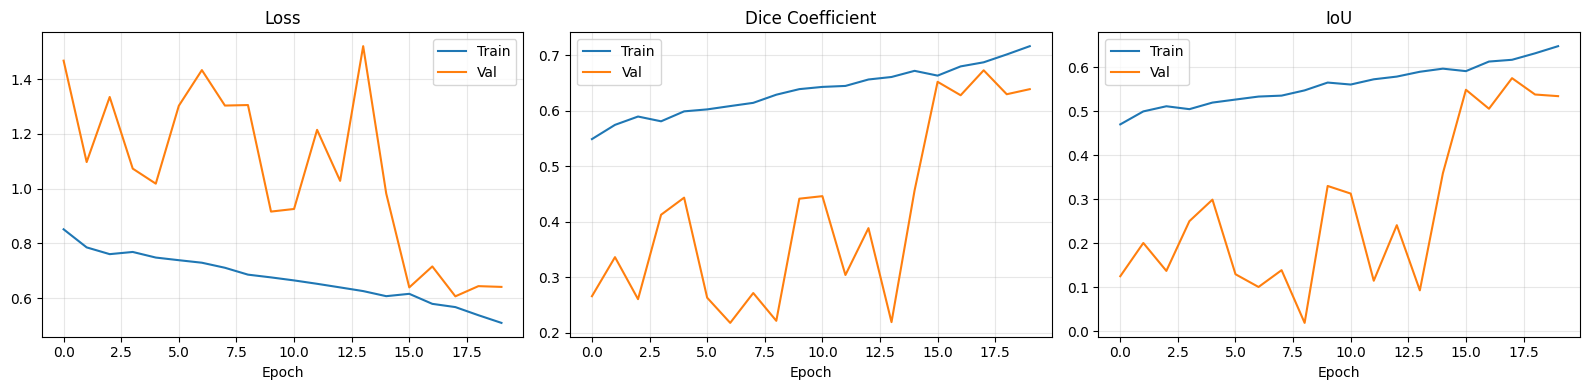

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, title in zip(axes, 
                          ['loss', 'dice_coefficient', 'iou_metric'],
                          ['Loss', 'Dice Coefficient', 'IoU']):
    ax.plot(history.history[key],        label='Train')
    ax.plot(history.history[f'val_{key}'], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bcdu_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Evaluate on Test Set

In [18]:
test_results = model.evaluate(test_ds)
metric_names = model.metrics_names
print("\nTest Set Results:")
for name, val in zip(metric_names, test_results):
    print(f"  {name}: {val:.4f}")

48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_coefficient: 0.7097 - iou_metric: 0.6149 - loss: 0.5728

2026-03-04 17:55:13.889069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:55:14.082472: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - dice_coefficient: 0.6496 - iou_metric: 0.5487 - loss: 0.6336

Test Set Results:
  loss: 0.6336
  compile_metrics: 0.6496


## 7. Qualitative Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


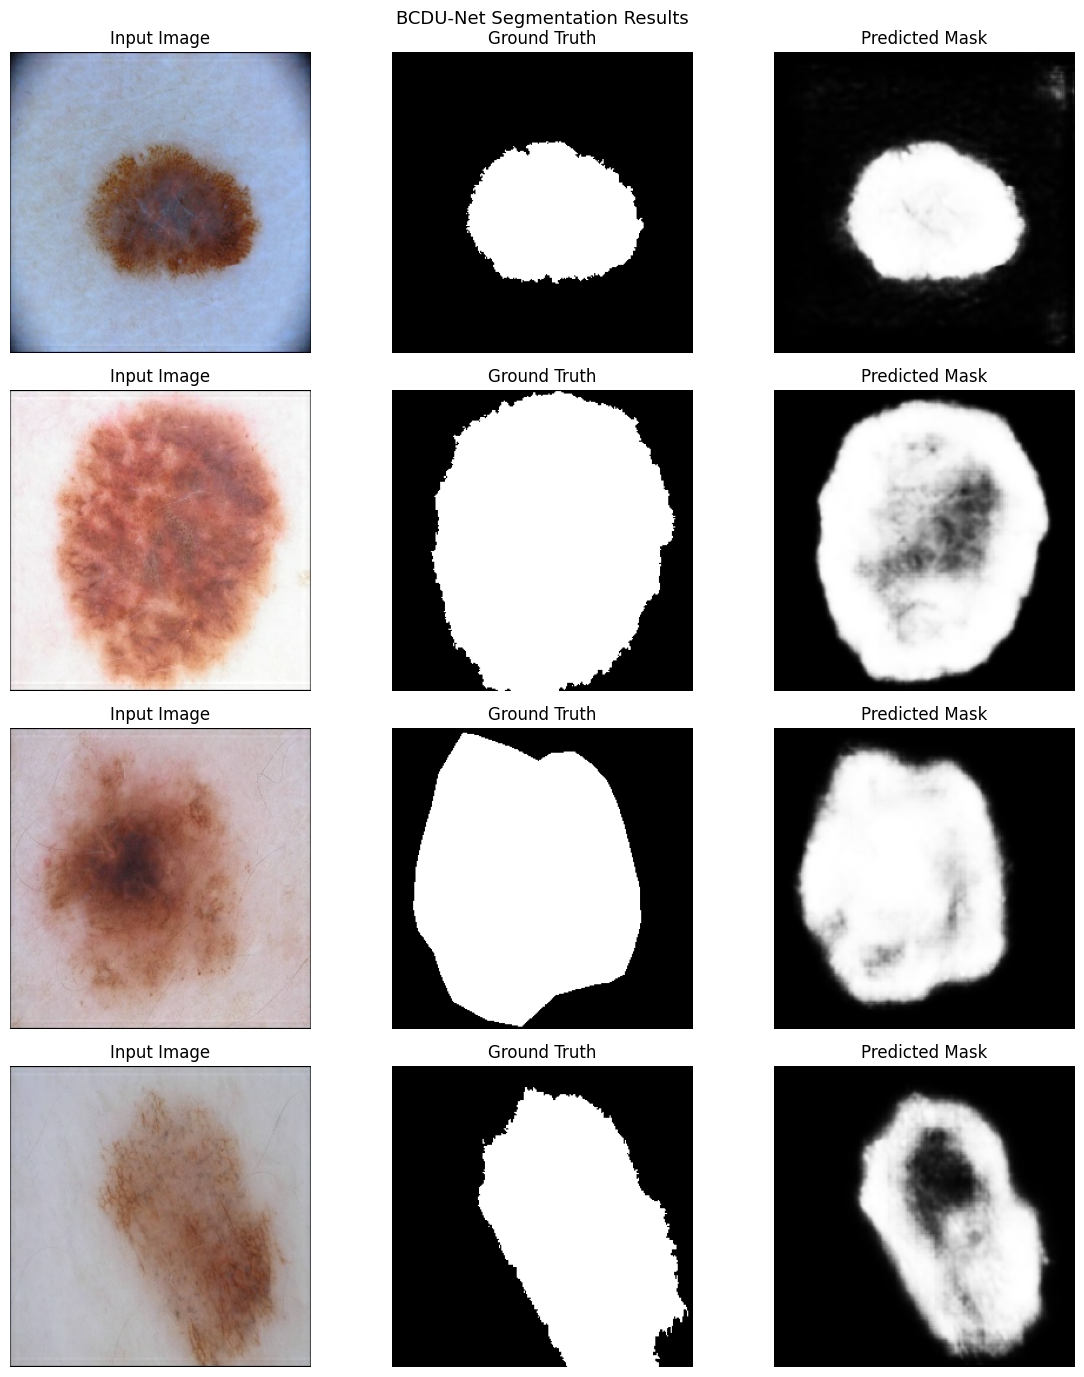

In [19]:
sample_batch_imgs, sample_batch_masks = next(iter(test_ds))
pred_masks = model.predict(sample_batch_imgs)

fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i in range(4):
    axes[i, 0].imshow(sample_batch_imgs[i].numpy())
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sample_batch_masks[i, :, :, 0].numpy(), cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_masks[i, :, :, 0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.suptitle("BCDU-Net Segmentation Results", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bcdu_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Apply Masks to Classification Images
We apply the trained segmenter to the full classification training set to create segmented images for use in Notebook 15. For each preprocessed classification image, we predict the mask and zero out background pixels.

In [20]:
CLASSIFICATION_DIR = DATA_DIR / "processed" / "classification"
SEGMENTED_DIR      = DATA_DIR / "processed" / "segmented"
SEGMENTED_DIR.mkdir(parents=True, exist_ok=True)

In [21]:
def apply_mask_to_image(img_bgr, pred_mask, threshold=0.5):
    """Zero out background pixels using predicted mask."""
    binary_mask = (pred_mask[:, :, 0] > threshold).astype(np.uint8)
    result = img_bgr.copy()
    result[binary_mask == 0] = 0
    return result

In [22]:
# Process all classification images in batches
cls_image_files = sorted(CLASSIFICATION_DIR.glob("*.jpg"))
print(f"Classification images to segment: {len(cls_image_files)}")

Classification images to segment: 10015


In [23]:
success = 0

for img_path in cls_image_files:
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_input = img_rgb[np.newaxis, ...]  # add batch dim

    pred = model.predict(img_input, verbose=0)
    segmented = apply_mask_to_image(img_bgr, pred[0])

    out_path = SEGMENTED_DIR / img_path.name
    cv2.imwrite(str(out_path), segmented)
    success += 1

print(f"Segmented images saved: {success}")

2026-03-04 17:55:29.016135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:55:29.202906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:55:29.635893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:55:29.848845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Segmented images saved: 10015


In [25]:
bcdu_summary = {
    "model": "BCDU-Net",
    "epochs_trained": len(history.history['loss']),
    "test_metrics": dict(zip(metric_names, [float(v) for v in test_results])),
    "segmented_images": success,
    "output_dir": str(SEGMENTED_DIR)
}

with open(RESULTS_DIR / "bcdu_summary.json", "w") as f:
    json.dump(bcdu_summary, f, indent=2)

print("BCDU-Net training and inference complete.")

BCDU-Net training and inference complete.
